# ДОМАШНЕЕ ЗАДАНИЕ 2. Модели предсказания

Выполнил Фадеев Роман Андреевич гр. ИУ6-21М

## Оглавление

[Цель работы](#goal)

[Вариант](#variant)

[Задача 1. Реализация собственных классов и функций](#task1)

[Задача 2. Классификация и кросс-валидация](#task2)

[Задача 3. Классификация текстовых документов](#task3)

<a id="goal"></a>

## Цель работы

Приобрести опыт решения практических задач по машинному обучению, таких как анализ и визуализация исходных данных, обучение, выбор и оценка качества моделей предсказания, посредством языка программирования Python.

При выполнении работы решаются следующие задачи:

- реализация собственных классов совместимых с библиотекой `sklearn`
- оценка влияния регуляризации в моделях предсказания
- преобразование исходных данных посредством транформаторов `sklearn`
- использование отложенной выборки и кросс-валидации
- выбор гиперпараметров и интерпретация кривых обучения
- оценка качества моделей предсказания
- выявление преимуществ и недостатков методов предсказания в зависимости от поставленной задачи

<a id="variant"></a>

## Вариант 

Чтобы узнать свой вариант, введите Вашу фамилию в соответствующее поле ниже и запустите ячейку:

In [64]:
surname = "Фадеев"  # Ваша фамилия

alph = 'абвгдеёжзийклмнопрстуфхцчшщъыьэюя'
w = [4, 42, 21, 21, 55,  1, 44, 26, 18, 3, 38, 26, 18, 12,  3, 49, 45,
        7, 42, 9,  4,  3, 36, 33, 31, 29,  5, 4,  4, 19, 21, 27, 33]
d = dict(zip(alph, w))
variant =  sum([d[el] for el in surname.lower()]) % 40 + 1

print("Задание № 2. Вариант: ", variant % 2 + 1)
print("Задание № 3. Вариант: ", variant % 3 + 1 )

Задание № 2. Вариант:  1
Задание № 3. Вариант:  1


<a id="task1"></a>

## Задача 1. Реализация собственных классов и функций (4 балла)

⚠️ **Замечание.** 1) Нельзя пользоваться готовыми реализациями `sklearn`; 2) чтобы избежать случая с вырожденной матрицей при оценке параметров добавьте незначительную регуляризацию по умолчанию или используйте `lstsq` из пакета `numpy` или др. способ; 3) используйте `random_state=0`

1. Реализуйте класс, предназначенный для оценки параметров линейной регрессии с L2 регуляризацией совместимый с `sklearn`. Передаваемые параметры: 1) коэффициент регуляризации (`alpha`). Использовать метод наименьших квадратов с L2 регуляризацией.

In [65]:
import numpy as np
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.utils.validation import check_X_y, check_array, check_is_fitted

class MyRidgeRegression(BaseEstimator, RegressorMixin):
    def __init__(self, alpha=1.0, fit_intercept=True):
        self.alpha = alpha
        self.fit_intercept = fit_intercept

    def fit(self, X, y):
        X, y = check_X_y(X, y)

        n_samples, _ = X.shape

        if self.fit_intercept:
            X_bias = np.hstack([np.ones((n_samples, 1)), X])
        else:
            X_bias = X

        n_params = X_bias.shape[1]
        I = np.eye(n_params)

        if self.fit_intercept:
            I[0, 0] = 0

        # w = (X^T X + alpha * I)^(-1) X^T y
        A = X_bias.T @ X_bias + self.alpha * I
        b = X_bias.T @ y

        w = np.linalg.lstsq(A, b, rcond=None)[0]

        if self.fit_intercept:
            self.intercept_ = w[0]
            self.coef_ = w[1:]
        else:
            self.intercept_ = 0.0
            self.coef_ = w

        return self

    def predict(self, X):
        check_is_fitted(self, ["coef_", "intercept_"])

        X = check_array(X)

        return X @ self.coef_ + self.intercept_

    def score(self, X, y):
        y_pred = self.predict(X)

        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)

        return 1 - ss_res / ss_tot

2. Реализуйте класс для стандартизации признаков в виде трансформации совместимый с `sklearn`. Передаваемые параметры: 1) `has_bias` (содержит ли  матрица вектор единиц), 2) `apply_mean` (производить ли центровку)

In [66]:
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.utils.validation import check_array, check_is_fitted


class MyStandardScaler(BaseEstimator, TransformerMixin):
    def __init__(self, has_bias=False, apply_mean=True):
        self.has_bias = has_bias
        self.apply_mean = apply_mean

    def fit(self, X, y=None):
        X = check_array(X)

        n_features = X.shape[1]

        start_idx = 1 if self.has_bias else 0

        self.mean_ = np.zeros(n_features)
        self.scale_ = np.ones(n_features)

        if self.apply_mean:
            self.mean_[start_idx:] = np.mean(
                X[:, start_idx:],
                axis=0
            )

        self.scale_[start_idx:] = np.std(
            X[:, start_idx:],
            axis=0
        )

        self.scale_[self.scale_ == 0] = 1.0

        return self

    def transform(self, X):
        check_is_fitted(self, ["mean_", "scale_"])

        X = check_array(X)

        X_transformed = X.copy()

        start_idx = 1 if self.has_bias else 0

        X_transformed[:, start_idx:] = (
            X_transformed[:, start_idx:] - self.mean_[start_idx:]
        ) / self.scale_[start_idx:]

        return X_transformed

    def fit_transform(self, X, y=None):
        return self.fit(X, y).transform(X)

3. Реализуйте функции для расчета `MSE` и `R^2` при отложенной выборке (`run_holdout`) и кросс-валидации (`run_cross_val`). Для кросс-валидации используйте **только** класс `KFold`. Выходными значениями должны быть `MSE` и `R^2` для обучающей и тестовой частей.

    *Шаблон кода:*

    ```python
    def run_holdout(model, X, y, train_size, random_state) -> dict:
        ...
        return scores


    def run_cross_val(model, X, y, n_splits, shuffle, random_state) -> dict:
        ...
        return scores
    ```

In [67]:
import numpy as np

from sklearn.model_selection import (
    train_test_split,
    KFold
)

from sklearn.metrics import (
    mean_squared_error,
    r2_score
)

from sklearn.base import clone


def run_holdout(model, X, y, train_size=0.8, random_state=0) -> dict:
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        train_size=train_size,
        random_state=random_state
    )

    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    scores = {
        "train_mse": mean_squared_error(y_train, y_train_pred),
        "test_mse": mean_squared_error(y_test, y_test_pred),

        "train_r2": r2_score(y_train, y_train_pred),
        "test_r2": r2_score(y_test, y_test_pred)
    }

    return scores


def run_cross_val(
    model,
    X,
    y,
    n_splits=5,
    shuffle=True,
    random_state=0
) -> dict:
    kf = KFold(
        n_splits=n_splits,
        shuffle=shuffle,
        random_state=random_state
    )

    train_mse_scores = []
    test_mse_scores = []

    train_r2_scores = []
    test_r2_scores = []

    for train_idx, test_idx in kf.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        current_model = clone(model)

        current_model.fit(X_train, y_train)

        y_train_pred = current_model.predict(X_train)
        y_test_pred = current_model.predict(X_test)

        train_mse_scores.append(
            mean_squared_error(y_train, y_train_pred)
        )

        test_mse_scores.append(
            mean_squared_error(y_test, y_test_pred)
        )

        train_r2_scores.append(
            r2_score(y_train, y_train_pred)
        )

        test_r2_scores.append(
            r2_score(y_test, y_test_pred)
        )

    scores = {
        "train_mse": np.mean(train_mse_scores),
        "test_mse": np.mean(test_mse_scores),

        "train_r2": np.mean(train_r2_scores),
        "test_r2": np.mean(test_r2_scores)
    }

    return scores

4. Выполните обучение линейной регрессии с регуляризацией, используя ранее реализованные классы и функции. Для этого воспользуйтесь `Pipeline` со стандартизацией и линейной регрессией (см. п.1 и п.2). Для линейной регрессии используйте следующие коэффициенты регуляризации: `0` и `0.01`. Для оценки качества моделей выведите значения `MSE` и `R^2`, полученные посредством функций `run_holdout` и `run_cross_val`. Повторно обучите модели с разными коэффициентами регуляризации на всем наборе данных и выведите параметры моделей.

Необходимо использовать следующие параметры:
    - `train_size=0.75`, 
    - `n_splits=4`, 
    - `shuffle=True`, 
    - `random_state=0`

In [68]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline

df = pd.read_csv("hw2/data/regularization.csv")

target_column_name = "Y"
X = df.drop(columns=[target_column_name]).values
y = df[target_column_name].values

alphas = [0, 0.01]

for alpha in alphas:
    print("-*-" * 20)
    print(f"Ридж регрессия при alpha = {alpha}")
    print("-*-" * 20)

    model = Pipeline([
        ("scaler", MyStandardScaler(
            has_bias=False,
            apply_mean=True
        )),
        ("regressor", MyRidgeRegression(
            alpha=alpha,
            fit_intercept=True
        ))
    ])

    holdout_scores = run_holdout(
        model=model,
        X=X,
        y=y,
        train_size=0.75,
        random_state=0
    )

    print("\nРезультаты с отложенной выборкой")
    print(f"Train MSE: {holdout_scores['train_mse']:.6f}")
    print(f"Test  MSE: {holdout_scores['test_mse']:.6f}")
    print(f"Train R2 : {holdout_scores['train_r2']:.6f}")
    print(f"Test  R2 : {holdout_scores['test_r2']:.6f}")


    cv_scores = run_cross_val(
        model=model,
        X=X,
        y=y,
        n_splits=4,
        shuffle=True,
        random_state=0
    )

    print("\nРезультаты кросс-валидации")
    print(f"Train MSE: {cv_scores['train_mse']:.6f}")
    print(f"Test  MSE: {cv_scores['test_mse']:.6f}")
    print(f"Train R2 : {cv_scores['train_r2']:.6f}")
    print(f"Test  R2 : {cv_scores['test_r2']:.6f}")

    model.fit(X, y)

    reg = model.named_steps["regressor"]

    print("\nПараметры модели")
    print("Intercept:", reg.intercept_)
    print("Coefficients:", reg.coef_)
    print("\n")

-*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*-
Ридж регрессия при alpha = 0
-*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*-

Результаты с отложенной выборкой
Train MSE: 0.219427
Test  MSE: 0.232520
Train R2 : 0.691848
Test  R2 : 0.689894

Результаты кросс-валидации
Train MSE: 0.216342
Test  MSE: 0.240553
Train R2 : 0.700198
Test  R2 : 0.664733

Параметры модели
Intercept: 9.448921018562729
Coefficients: [ 7.12865811e+00 -1.42129371e+02  1.19642423e+03 -5.12922815e+03
  1.14301154e+04 -1.08837259e+04 -2.59485366e+03  9.57656128e+03
  3.93538322e+03 -7.38809433e+03 -7.70066252e+03  2.82400582e+03
  1.00028569e+04  2.13320848e+03 -1.25720522e+04  5.30494865e+03]


-*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*-
Ридж регрессия при alpha = 0.01
-*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*--*-

Результаты с отложенной выборкой
Train MSE: 0.227031
Test  MSE: 0.226222
Train R2 : 0.681170
Test  R2 : 0.698293

Результаты кросс-валидации
Train M

5. Отобразите предсказания и действительные значения в виде диаграммы разброса. Для этого сформируйте обучающее и тестовое множества (в данном случае можно использовать `train_test_split`). Используйте `Pipeline` и коэффициенты регуляризации из предыдущего пункта. Обучите линейную регрессию на обучающем множестве. Выведите графики предсказание ($\hat{y}$) - действительное значение ($y$) для разных коэффициентов регуляризации для тестовой части. 

⚠️ **Замечание.** При формировании исходных данных использовался полином 16 степени одномерных данных. 

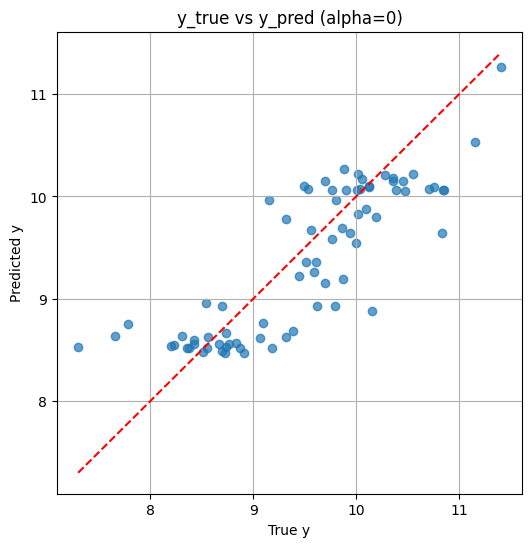

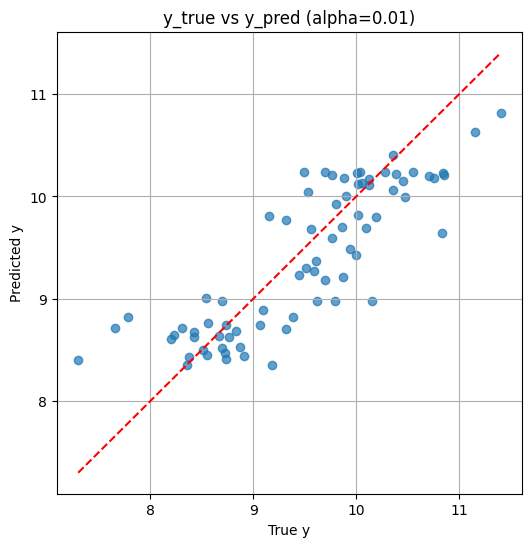

In [69]:
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size=0.75,
    random_state=0
)

def build_model(alpha):
    return Pipeline([
        ("scaler", MyStandardScaler(has_bias=False, apply_mean=True)),
        ("regressor", MyRidgeRegression(alpha=alpha, fit_intercept=True))
    ])

alphas = [0, 0.01]

for alpha in alphas:
    model = build_model(alpha)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, y_pred, alpha=0.7)

    mn = min(y_test.min(), y_pred.min())
    mx = max(y_test.max(), y_pred.max())

    plt.plot([mn, mx], [mn, mx], "r--")

    plt.title(f"y_true vs y_pred (alpha={alpha})")
    plt.xlabel("True y")
    plt.ylabel("Predicted y")
    plt.grid(True)

    plt.show()

<a id="task2"></a>

## Задача 2. Классификация и кросс-валидация (2 балла)

⚠️ **Замечание**:
- Используйте класс логистической регрессии из `sklearn` со следующими параметрами:
    - `penalty='l2'`
    - `fit_intercept=True`
    - `max_iter=100`
    - `C=1e5`
    - `solver='liblinear'`
    - `random_state=12345`
- Разбейте исходные данные на обучающее и тестовое подмножества в соотношении `70` на `30`, `random_state=0`
- Для выбора гиперпараметров используйте два подхода: 1) с отложенной выборкой, 2) с кросс-валидацией
- Для кросс-валидации использовать функцию `cross_validate` из `sklearn`
- Параметры разбиения для выбора гиперпараметров используйте те, что в п.4 задачи 1

Дано множество наблюдений (см. набор данных к заданию), классификатор - логистическая регрессия. Найти степень полинома с минимальной ошибкой на проверочном подмножестве. Для лучшего случая рассчитать ошибку на тестовом подмножестве. В качестве метрики использовать долю правильных классификаций. Сделать заключение о влиянии степени полинома на качество предсказания.

Построить:
- диаграмму разброса исходных данных
- зависимость доли правильных классификаций от степени полинома для обучающего и проверочного подмножеств (две кривые на одном графике)
- результат классификации для наилучшего случая (степень полинома) для обучающего и тестового подмножеств с указанием границы принятия решения

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import (
    train_test_split,
    cross_validate
)

from sklearn.metrics import accuracy_score

df = pd.read_csv("./hw2/data/Cl_A5_V1.csv")

X = df[["X1", "X2"]].values
y = df["y"].values

In [71]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=0,
    stratify=y
)


X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.3,
    random_state=0,
    stratify=y_train_full
)

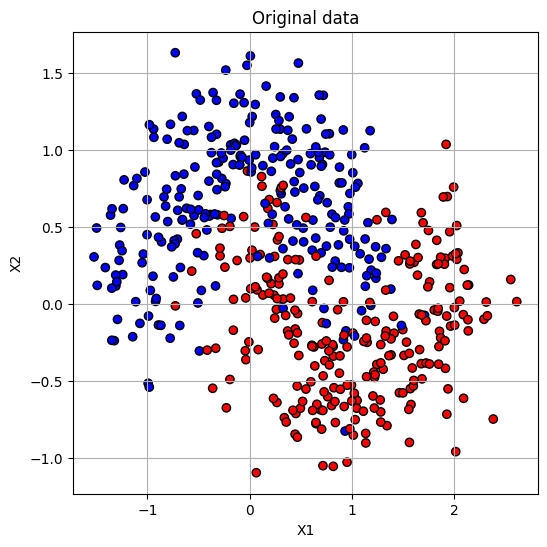

In [72]:
plt.figure(figsize=(6, 6))

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap="bwr",
    edgecolor="k"
)

plt.xlabel("X1")
plt.ylabel("X2")
plt.title("Original data")
plt.grid(True)

plt.show()

In [73]:
def make_model(degree):
    return Pipeline([
        (
            "poly",
            PolynomialFeatures(degree=degree)
        ),
        (
            "clf",
            LogisticRegression(
                penalty='l2',
                fit_intercept=True,
                max_iter=100,
                C=1e5,
                solver='liblinear',
                random_state=12345
            )
        )
    ])

In [74]:
degrees = range(1, 11)

train_acc_holdout = []
val_acc_holdout = []

cv_train_acc = []
cv_val_acc = []

for d in degrees:
    model = make_model(d)

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    train_acc_holdout.append(
        accuracy_score(y_train, train_pred)
    )

    val_acc_holdout.append(
        accuracy_score(y_val, val_pred)
    )

    scores = cross_validate(
        model,
        X_train_full,
        y_train_full,
        cv=4,
        scoring="accuracy",
        return_train_score=True
    )

    cv_train_acc.append(
        scores["train_score"].mean()
    )

    cv_val_acc.append(
        scores["test_score"].mean()
    )

/usr/local/lib/python3.11/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/site-packages/sklearn/svm/_base.py:1235: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


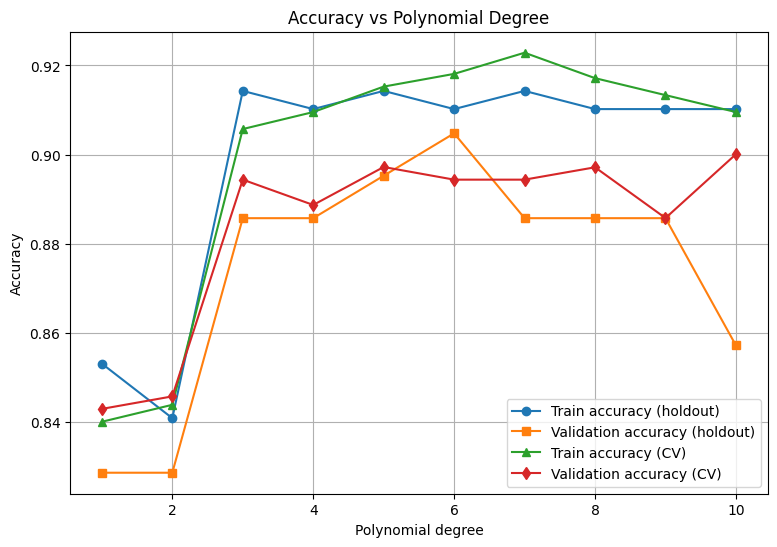

In [75]:
plt.figure(figsize=(9, 6))

plt.plot(
    degrees,
    train_acc_holdout,
    "o-",
    label="Train accuracy (holdout)"
)

plt.plot(
    degrees,
    val_acc_holdout,
    "s-",
    label="Validation accuracy (holdout)"
)

plt.plot(
    degrees,
    cv_train_acc,
    "^-",
    label="Train accuracy (CV)"
)

plt.plot(
    degrees,
    cv_val_acc,
    "d-",
    label="Validation accuracy (CV)"
)

plt.xlabel("Polynomial degree")
plt.ylabel("Accuracy")

plt.title("Accuracy vs Polynomial Degree")

plt.legend()
plt.grid(True)

plt.show()

In [76]:
best_degree = degrees[np.argmax(val_acc_holdout)]

print("Оптимальная степень полинома:", best_degree)

Оптимальная степень полинома: 6


In [77]:
best_model = make_model(best_degree)

best_model.fit(X_train_full, y_train_full)

Pipeline(steps=[('poly', PolynomialFeatures(degree=6)),
                ('clf',
                 LogisticRegression(C=100000.0, random_state=12345,
                                    solver='liblinear'))])

In [78]:
y_test_pred = best_model.predict(X_test)

test_accuracy = accuracy_score(
    y_test,
    y_test_pred
)

print("Test accuracy:", test_accuracy)

Test accuracy: 0.9133333333333333


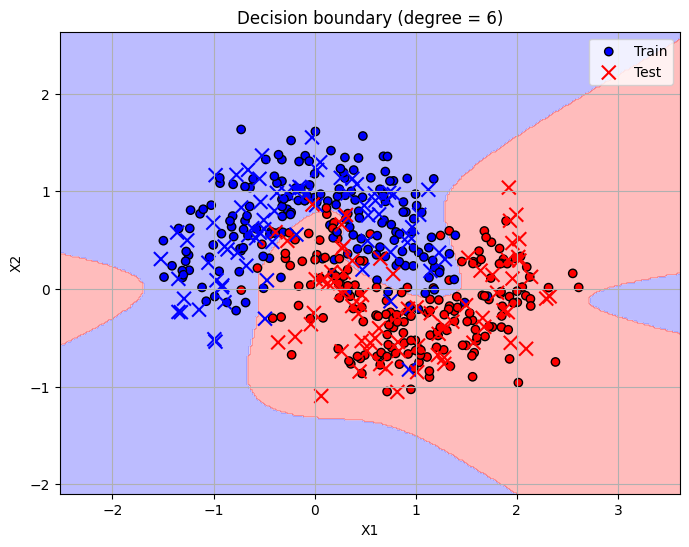

In [79]:
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]

Z = best_model.predict(grid)
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.3,
    cmap="bwr"
)

plt.scatter(
    X_train_full[:, 0],
    X_train_full[:, 1],
    c=y_train_full,
    cmap="bwr",
    edgecolor="k",
    label="Train"
)

plt.scatter(
    X_test[:, 0],
    X_test[:, 1],
    c=y_test,
    cmap="bwr",
    marker="x",
    s=100,
    label="Test"
)

plt.xlabel("X1")
plt.ylabel("X2")

plt.title(
    f"Decision boundary (degree = {best_degree})"
)

plt.legend()
plt.grid(True)

plt.show()

**Вывод:** Увеличение степени полинома, в целом, коррелирует с улучшением точности модели, однако для такой простой задачи слишком большая степень ведет к переобучению - точность на валидационном множестве снижается, в то время как на обучающем продолжает расти.

<a id="task3"></a>

## Задача 3. Классификация текстовых документов (4 балла)

1. Загрузите исходные данные
2. Разбейте исходные данные на обучающее (train, 80%) и тестовое подмножества (test, 20%)
3. Используя стратифицированную кросс-валидацию k-folds ($k=4$) для обучающего множество с метрикой `Balanced-Accuracy`, найдите лучшие гиперпараметры для следующих классификаторов:
    - K-ближайших соседей: количество соседей ($n$) из диапазона `np.arange(1, 150, 20)`
    - Логистическая регрессия: параметр регуляризации ($C$) из диапазона `np.logspace(-2, 10, 8, base=10)`
    - Наивный Байес: сглаживающий параметр модели Бернулли ($\alpha$) из диапазона `np.logspace(-4, 1, 8, base=10)`
    - Наивный Байес: сглаживающий параметр полиномиальной модели ($\alpha$) из диапазона `np.logspace(-4, 1, 8, base=10)`

4. Отобразите кривые (параметры модели)-(`Balanced-Accuracy`) при обучении и проверке для каждой классификатора (две кривые на одном графике для каждого классификатора)
5. Если необходимо, выбранные модели обучите на всём обучающем подмножестве (train) и протестируйте на тестовом (test) по `Balanced-Accuracy`, `R`, `P`, `F1`. Определите время обучения и предсказания.
6. Выполните пункты 3-5 для `n-gram=1`, `n-gram=2` и `n-gram=(1,2)`
7. Выведите в виде таблицы итоговые данные по всем методам для лучших моделей (метод, n-gram, значение параметра модели, время обучения, время предсказания, метрики (`Balanced-Accuracy`, `R`, `P`, `F1`))
8. Сделайте выводы по полученным результатам (преимущества и недостатки методов)

⚠️ **Замечание:** 
- Для всех объектов/методов/моделей `random_state = 123`
- Для выбора гиперпараметров можно использовать стандартные утилиты `sklearn`

Импортируем библиотеки и загружаем TSV

In [80]:
import numpy as np
import pandas as pd
import time

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.metrics import balanced_accuracy_score, precision_score, recall_score, f1_score

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import BernoulliNB, MultinomialNB

In [81]:
df = pd.read_csv(
    "./hw2/data/emails.tsv",
    sep="\t",
    engine="python",
    header=None,
    on_bad_lines="skip"
)

df = df.dropna()
df.columns = ["label", "text"]

X = df["text"].astype(str).to_numpy()
y = df["label"].to_numpy().astype(int)

Разбиваем данные на train/test

In [82]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=123,
    stratify=y
)

Зададим необходимые модели и их параметры

In [83]:
param_grid = {
    "knn": {
        "model": KNeighborsClassifier(),
        "params": {
            "clf__n_neighbors": np.arange(1, 150, 20)
        }
    },
    "logreg": {
        "model": LogisticRegression(
            max_iter=200,
            solver="liblinear",
            random_state=123
        ),
        "params": {
            "clf__C": np.logspace(-2, 10, 8, base=10)
        }
    },
    "bernoulli": {
        "model": BernoulliNB(),
        "params": {
            "clf__alpha": np.logspace(-4, 1, 8)
        }
    },
    "multinomial": {
        "model": MultinomialNB(),
        "params": {
            "clf__alpha": np.logspace(-4, 1, 8)
        }
    }
}

Методы для построения пайплайна и для отображения кривых (параметры модели)-(`Balanced-Accuracy`) при обучении

In [84]:
def build_pipeline(model, ngram):
    return Pipeline([
        ("vec", CountVectorizer(ngram_range=ngram)),
        ("clf", model)
    ])

In [85]:
def plot_cv(grid, title):
    res = pd.DataFrame(grid.cv_results_)

    param_col = [c for c in res.columns if c.startswith("param_")][0]

    x = res[param_col].astype(float)

    plt.figure(figsize=(6,4))

    plt.plot(x, res["mean_test_score"],
             marker="o", label="Validation")

    plt.plot(x, res["mean_train_score"],
             marker="o", label="Train")

    if "C" in param_col or "alpha" in param_col:
        plt.xscale("log")

    plt.xlabel(param_col.replace("param_", ""))
    plt.ylabel("Balanced Accuracy")

    plt.title(title)

    plt.legend()
    plt.grid()

    plt.show()

Обучение и сбор метрик определенных выше моделей

Note: you may need to restart the kernel to use updated packages.


  0%|                                                                             | 0/12 [00:00<?, ?it/s]

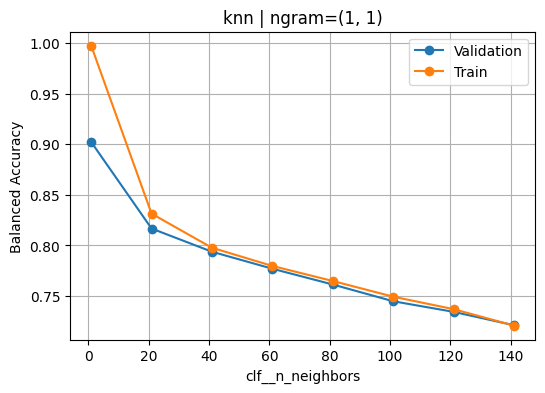

  8%|█████▊                                                               | 1/12 [00:29<05:22, 29.34s/it]

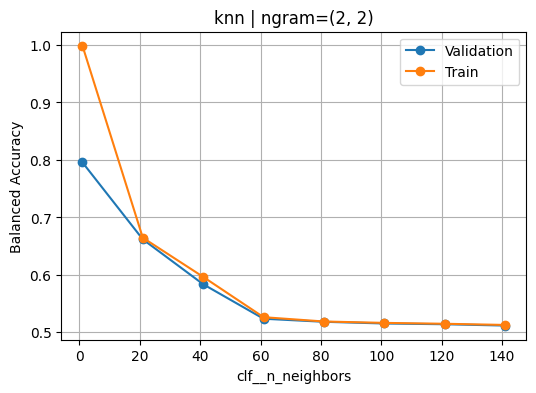

 17%|███████████▌                                                         | 2/12 [01:03<05:19, 31.94s/it]

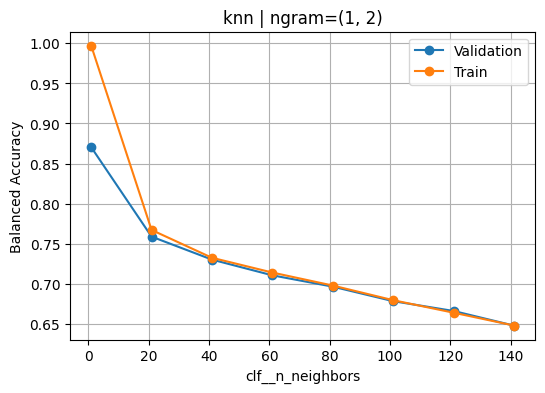

 25%|█████████████████▎                                                   | 3/12 [01:46<05:34, 37.19s/it]

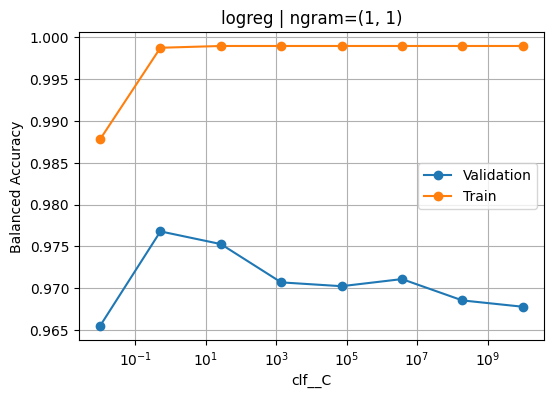

 33%|███████████████████████                                              | 4/12 [02:03<03:52, 29.06s/it]

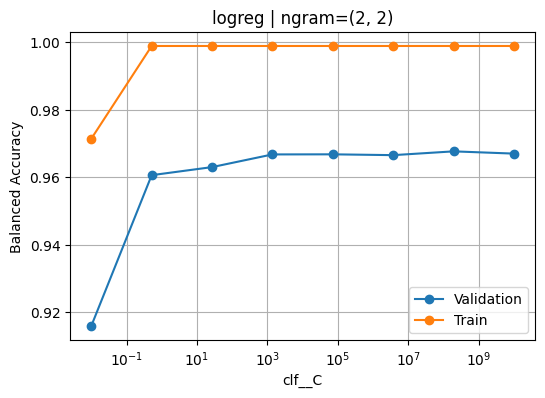

 42%|████████████████████████████▊                                        | 5/12 [02:53<04:17, 36.81s/it]

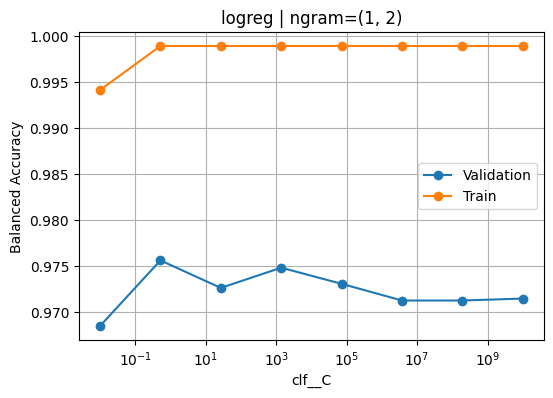

 50%|██████████████████████████████████▌                                  | 6/12 [04:08<04:59, 49.88s/it]

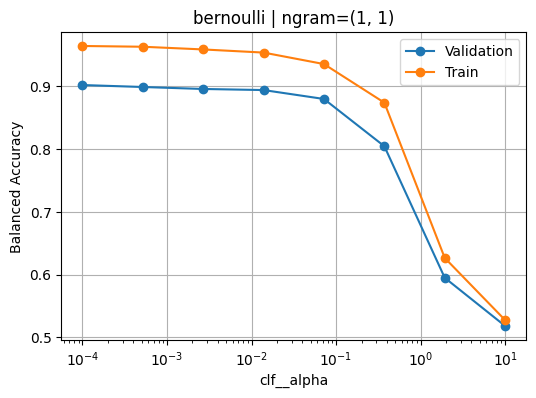

 58%|████████████████████████████████████████▎                            | 7/12 [04:17<03:02, 36.43s/it]

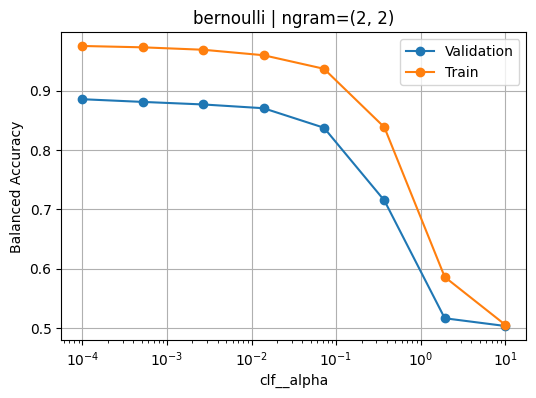

 67%|██████████████████████████████████████████████                       | 8/12 [04:36<02:03, 30.95s/it]

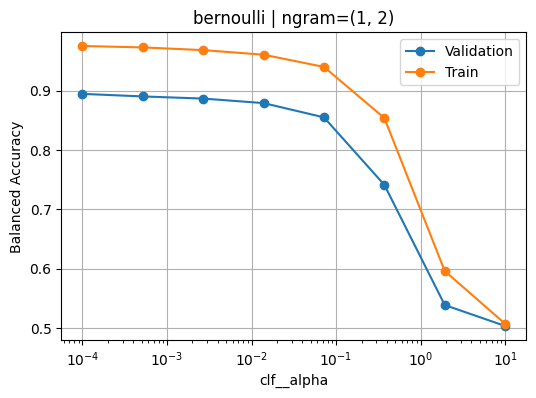

 75%|███████████████████████████████████████████████████▊                 | 9/12 [05:05<01:30, 30.20s/it]

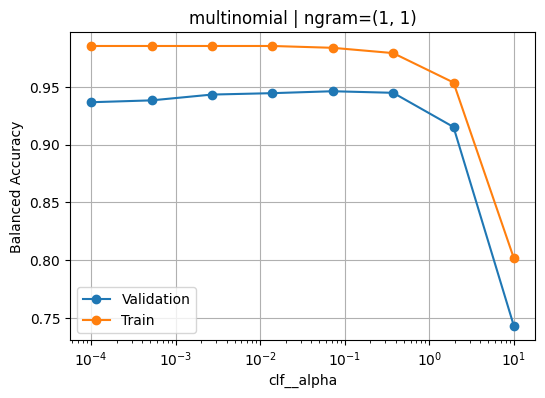

 83%|████████████████████████████████████████████████████████▋           | 10/12 [05:13<00:46, 23.48s/it]

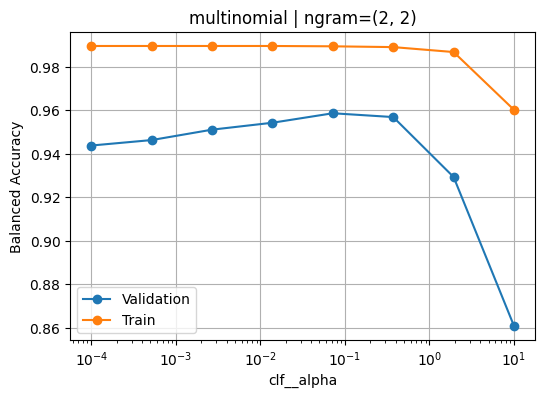

 92%|██████████████████████████████████████████████████████████████▎     | 11/12 [05:34<00:22, 22.58s/it]

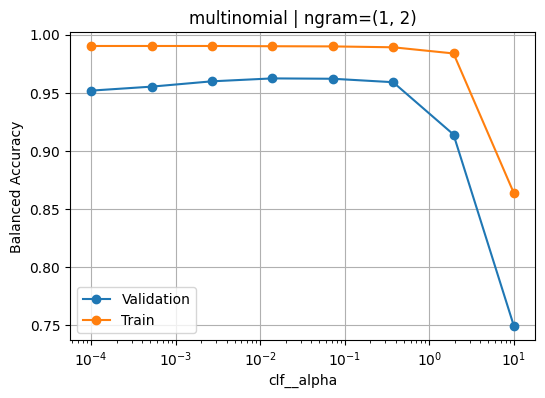

100%|████████████████████████████████████████████████████████████████████| 12/12 [05:59<00:00, 30.00s/it]


In [86]:
%pip install tqdm

from tqdm import tqdm

ngrams = [(1,1), (2,2), (1,2)]
results_table = []

total_iters = len(param_grid) * len(ngrams)

with tqdm(total=total_iters) as pbar:
    for name, cfg in param_grid.items():
        for ngram in ngrams:
            pipe = build_pipeline(cfg["model"], ngram)

            grid = GridSearchCV(
                pipe,
                cfg["params"],
                cv=StratifiedKFold(n_splits=4, shuffle=True, random_state=123),
                scoring="balanced_accuracy",
                return_train_score=True,
                n_jobs=-1
            )

            start_train = time.time()
            grid.fit(X_train, y_train)
            plot_cv(grid, f"{name} | ngram={ngram}")
            train_time = time.time() - start_train

            best_model = grid.best_estimator_

            start_pred = time.time()
            y_pred = best_model.predict(X_test)
            pred_time = time.time() - start_pred

            ba = balanced_accuracy_score(y_test, y_pred)
            p = precision_score(y_test, y_pred, average="weighted")
            r = recall_score(y_test, y_pred, average="weighted")
            f1 = f1_score(y_test, y_pred, average="weighted")

            results_table.append({
                "model": name,
                "ngram": ngram,
                "best_param": grid.best_params_,
                "train_time": train_time,
                "pred_time": pred_time,
                "balanced_acc": ba,
                "precision": p,
                "recall": r,
                "f1": f1
            })

            pbar.update(1)

Отображение результатов обучения/инференса моделей

In [89]:
results_df = pd.DataFrame(results_table)

results_df = results_df.sort_values(by="balanced_acc", ascending=False)

results_df

,model,ngram,best_param,train_time,pred_time,balanced_acc,precision,recall,f1
5,logreg,"(1, 2)",{'clf__C': 0.517947467923121},74.880328,0.345656,0.981217,0.984954,0.984971,0.984949
3,logreg,"(1, 1)",{'clf__C': 0.517947467923121},16.431293,0.128249,0.977704,0.981479,0.981503,0.981485
4,logreg,"(2, 2)",{'clf__C': 193069772.88832456},50.332981,0.227823,0.974438,0.975912,0.975723,0.975780
11,multinomial,"(1, 2)",{'clf__alpha': 0.013894954943731374},25.228382,0.316936,0.973097,0.979176,0.979191,0.979129
10,multinomial,"(2, 2)",{'clf__alpha': 0.07196856730011521},20.282803,0.236206,0.968490,0.976950,0.976879,0.976762
9,multinomial,"(1, 1)",{'clf__alpha': 0.07196856730011521},8.297489,0.127808,0.948983,0.959411,0.959538,0.959354
6,bernoulli,"(1, 1)",{'clf__alpha': 0.0001},8.587722,0.143290,0.915763,0.945551,0.943353,0.942097
0,knn,"(1, 1)",{'clf__n_neighbors': 1},28.372707,0.958746,0.914129,0.914414,0.904046,0.905950
8,bernoulli,"(1, 2)",{'clf__alpha': 0.0001},28.221226,0.336210,0.912003,0.945307,0.942197,0.940722
7,bernoulli,"(2, 2)",{'clf__alpha': 0.0001},18.965434,0.231371,0.910185,0.944294,0.941040,0.939496


In [90]:
best = results_df.iloc[0]

print("Модель с лучшими метриками:")
print(best)

Модель с лучшими метриками:
model                                  logreg
ngram                                  (1, 2)
best_param      {'clf__C': 0.517947467923121}
train_time                          74.880328
pred_time                            0.345656
balanced_acc                         0.981217
precision                            0.984954
recall                               0.984971
f1                                   0.984949
Name: 5, dtype: object


**Выводы:**

1. **Логистическая регрессия (logreg)**
   - Преимущества: высокая точность, хорошая интерпретируемость, устойчивость к переобучению при правильной регуляризации;
   - Недостатки: требует подбора параметра регуляризации, может быть медленной на больших данных;

2. **K-ближайших соседей (knn)**
   - Преимущества: простота реализации, не требует обучения;
   - Недостатки: медленное предсказание, чувствительность к шуму, требует хранения всех обучающих данных;

3. **Наивный Байес Бернулли (bernoulli)**
   - Преимущества: очень быстрое обучение и предсказание, хорошо работает с бинарными признаками;
   - Недостатки: предположение о независимости признаков, может уступать в точности;

4. **Наивный Байес Мультиномиальный (multinomial)**
   - Преимущества: хорошо работает с частотными признаками (TF-IDF), быстрое обучение;
   - Недостатки: предположение о независимости признаков, чувствительность к параметру сглаживания.